# CRAFT++ Framework Demo 4 - DETIC目标检测完整流程

本notebook演示了CRAFT++框架使用**DETIC**进行目标检测的完整工作流程。

## 📋 工作流概述

1. **环境配置（Setup）** - 导入模块并配置LLM API
2. **数据加载（Data Loading）** - 从REFLECT数据集加载真实机器人执行数据
3. **DETIC初始化** - 使用优化的DETIC初始化方式（支持CUDA错误自动回退到CPU）
4. **模型初始化** - 初始化场景图构建器和环境记忆
5. **选择关键帧并加载RGB-D数据** - 处理整个数据集
6. **生成场景图（集成环境记忆）** - 构建带置信度分数的分层场景表示
7. **可视化场景图和检测结果**
8. **从场景图生成约束（动作感知）**
9. **编译约束为可执行代码**
10. **使用约束验证进行失败检测**
11. **渐进式解释和失败分析**
12. **总结和结果**


## Step 1: Setup and Imports


In [1]:
import os
import sys
import json
from pathlib import Path

# ============================================================================
# CRITICAL: Configure Hugging Face mirror FIRST (before any imports)
# ============================================================================
# This must be set BEFORE importing transformers or any huggingface modules
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '300'  # 5 minutes timeout

# Clear any already-loaded huggingface/transformers modules to ensure mirror is used
modules_to_clear = [m for m in list(sys.modules.keys()) 
                   if any(keyword in m for keyword in ['transformers', 'huggingface', 'tokenizers', 'sentence_transformers'])]
for m in modules_to_clear:
    try:
        del sys.modules[m]
    except:
        pass

# Also try to patch huggingface_hub if it's already loaded
try:
    import huggingface_hub
    if hasattr(huggingface_hub, 'constants'):
        huggingface_hub.constants.ENDPOINT = 'https://hf-mirror.com'
    if hasattr(huggingface_hub, 'set_endpoint'):
        huggingface_hub.set_endpoint('https://hf-mirror.com')
except:
    pass

print("✅ Configured Hugging Face mirror: https://hf-mirror.com")
print(f"   HF_ENDPOINT = {os.environ.get('HF_ENDPOINT')}")
print(f"   HF_HUB_DOWNLOAD_TIMEOUT = {os.environ.get('HF_HUB_DOWNLOAD_TIMEOUT')}")
print("\n💡 If you still see connection errors, try:")
print("   1. Restart the kernel (Kernel → Restart Kernel)")
print("   2. Re-run all cells from the beginning")
print("   3. This ensures transformers loads with the mirror configured")

# IMPORTANT: Add parent directory to path BEFORE importing other modules
# This allows access to both craft and reflect directories
parent_dir = Path.cwd().parent
parent_dir_str = str(parent_dir)
if parent_dir_str not in sys.path:
    sys.path.insert(0, parent_dir_str)
    print(f"✅ Added parent directory to path: {parent_dir_str}")

# Debug: Show current paths
print(f"Current working directory: {Path.cwd()}")
print(f"Python path (first 3): {sys.path[:3]}")

# Now import other modules
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, HTML

# Import zarr with error handling
try:
    import zarr
    # Verify zarr module is correct (not accidentally importing built-in open)
    if not hasattr(zarr, 'open') and not hasattr(zarr, 'open_group'):
        raise ImportError("zarr module does not have expected functions")
    print(f"✅ zarr module imported (version: {getattr(zarr, '__version__', 'unknown')})")
except ImportError as e:
    print(f"⚠️  Error importing zarr: {e}")
    print("   Please install zarr: pip install zarr")
    raise

try:
    from imagecodecs import imread
except ImportError:
    print("⚠️  imagecodecs not available, some image loading features may not work")
    imread = None

# Import CRAFT modules
from craft.core import SceneGraph, Node, Edge, TaskExecutor
from craft.core.environment_memory import EnvironmentMemory, ObjectMemory, RelationMemory
from craft.perception import SceneAnalyzer, ReflectSceneGraphBuilder
from craft.perception.mdetr_detector import MDETRDetector
# DeticClipDetector will be imported in Step 4 if using DETIC + CLIP approach
from craft.reasoning import (
    LLMPrompter, FailureAnalyzer, 
    ConstraintGenerator, CausalVerifier, ConsistencyVerifier
)
from craft.correction import CorrectionPlanner
from craft.utils import ReflectDataLoader, load_config

print("✅ All modules imported successfully!")
print("✅ Environment Memory module loaded (for real-world occlusion/noise handling)")
print("💡 Note: DETIC + CLIP detector will be imported in Step 4 if selected")


✅ Configured Hugging Face mirror: https://hf-mirror.com
   HF_ENDPOINT = https://hf-mirror.com
   HF_HUB_DOWNLOAD_TIMEOUT = 300

💡 If you still see connection errors, try:
   1. Restart the kernel (Kernel → Restart Kernel)
   2. Re-run all cells from the beginning
   3. This ensures transformers loads with the mirror configured
✅ Added parent directory to path: /home/fdse/zzy
Current working directory: /home/fdse/zzy/craft
Python path (first 3): ['/home/fdse/zzy', '/home/fdse/anaconda3/envs/reflect_env/lib/python39.zip', '/home/fdse/anaconda3/envs/reflect_env/lib/python3.9']


✅ zarr module imported (version: 2.18.2)
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
✅ All modules imported successfully!
✅ Environment Memory module loaded (for real-world occlusion/noise handling)
💡 Note: DETIC + CLIP detector will be imported in Step 4 if selected


## Step 2: Configuration and Data Path Setup


In [2]:
# Configuration
# ============================================================================

# REFLECT dataset root directory (adjust if needed)
REFLECT_ROOT = os.path.join(parent_dir, 'reflect')
CRAFT_ROOT = Path.cwd()

# Task selection - modify this to choose different tasks
# Note: Check available tasks in /home/leo/reflect/reflect_dataset/real_data/
TASK_FOLDER_NAME = "makeCoffee2"  # Example: makeCoffee2, makeCoffee1, putAppleBowl1, etc.

# LLM API configuration (set your API key)
API_KEY = os.getenv("OPENAI_API_KEY", "your-api-key-here")
LLM_MODEL = "gpt-3.5-turbo"  # or "gpt-4"

# Camera intrinsics (RealSense camera used in REFLECT)
CAMERA_INTRINSICS = {
    "fx": 914.27246,
    "fy": 913.2658,
    "cx": 647.0733,
    "cy": 356.32526
}

# Detection threshold for MDETR
# Lowered from 0.7 to 0.5 to improve detection rate for real-world images
DETECTION_THRESHOLD = 0.5

# Helper function to safely open zarr files
def safe_open_zarr(zarr_path, mode='r'):
    """
    Safely open a zarr file, handling different zarr API versions
    
    Args:
        zarr_path: Path to zarr file
        mode: Open mode ('r' for read, 'w' for write, etc.)
    
    Returns:
        Zarr group object
    """
    if not os.path.exists(zarr_path):
        raise FileNotFoundError(f"Zarr file not found: {zarr_path}")
    
    # Try different zarr API methods in order
    errors = []
    
    # Method 1: zarr.open_group (preferred for zarr v2+)
    if hasattr(zarr, 'open_group'):
        try:
            return zarr.open_group(zarr_path, mode=mode)
        except (AttributeError, TypeError) as e:
            errors.append(f"zarr.open_group failed: {e}")
    
    # Method 2: zarr.open with mode parameter
    if hasattr(zarr, 'open'):
        try:
            return zarr.open(zarr_path, mode=mode)
        except TypeError as e:
            errors.append(f"zarr.open with mode failed: {e}")
            # Method 3: zarr.open without mode (older API)
            try:
                return zarr.open(zarr_path)
            except Exception as e:
                errors.append(f"zarr.open without mode failed: {e}")
    
    # If all methods failed, raise with all error messages
    raise RuntimeError(f"Failed to open zarr file with any method. Errors: {'; '.join(errors)}")

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"REFLECT Root: {REFLECT_ROOT}")
print(f"CRAFT Root: {CRAFT_ROOT}")
print(f"Task Folder: {TASK_FOLDER_NAME}")
print(f"LLM Model: {LLM_MODEL}")
print(f"Detection Threshold: {DETECTION_THRESHOLD}")
print("=" * 60)


CONFIGURATION
REFLECT Root: /home/fdse/zzy/reflect
CRAFT Root: /home/fdse/zzy/craft
Task Folder: makeCoffee2
LLM Model: gpt-3.5-turbo
Detection Threshold: 0.5


## Step 3: Load Real-World Data from REFLECT Dataset


In [ ]:
# ============================================================================
# Step 3: Load Real-World Data from REFLECT Dataset
# ============================================================================

# Initialize data loader
from craft.utils.reflect_data_loader import ReflectDataLoader

data_loader = ReflectDataLoader(data_root=REFLECT_ROOT)

# Load task information
task_info = data_loader.load_task_info(TASK_FOLDER_NAME)

if task_info is None:
    print(f"⚠️  Task info not found for {TASK_FOLDER_NAME}")
    print("   Trying alternative path...")
    # Try loading from real-world directory
    tasks_json_path = os.path.join(REFLECT_ROOT, 'real-world', 'tasks_real_world.json')
    if os.path.exists(tasks_json_path):
        with open(tasks_json_path, 'r') as f:
            tasks_json = json.load(f)
        # Find task by folder name
        for task_key, task_data in tasks_json.items():
            if task_data.get("general_folder_name") == TASK_FOLDER_NAME:
                task_info = task_data
                break

if task_info is None:
    raise ValueError(f"Could not find task info for {TASK_FOLDER_NAME}")

print("=" * 60)
print("TASK INFORMATION")
print("=" * 60)
print(f"Task Name: {task_info.get('name', 'N/A')}")
print(f"Folder Name: {task_info.get('general_folder_name', 'N/A')}")
print(f"Object List: {task_info.get('object_list', [])}")
print(f"Actions: {task_info.get('actions', [])}")
print(f"Success Condition: {task_info.get('success_condition', 'N/A')}")
print(f"GT Failure Reason: {task_info.get('gt_failure_reason', 'N/A')}")
print("=" * 60)

# Load zarr file
try:
    zarr_group = data_loader.load_zarr_file(TASK_FOLDER_NAME)
    
    # Get total frames
    total_frames = data_loader.get_total_frames(zarr_group)
    print(f"✅ Successfully loaded zarr file")
    print(f"   Total frames: {total_frames}")
    
except Exception as e:
    print(f"⚠️  Error loading zarr file: {e}")
    raise



TASK INFORMATION
Task Name: make coffee
Folder Name: makeCoffee2
Object List: ['coffee machine', 'purple cup', 'blue cup with handle', 'table on the left of sink']
Actions: ['Pick up cup', 'Put cup in coffee machine', 'Toggle on coffee machine', 'Pick up cup', 'Put cup on table']
Success Condition: a cup filled with coffee is on table.
GT Failure Reason: A mug is already inside the coffee machine, as a result, the cup cannot be put inside.
✅ Successfully loaded zarr file
   Total frames: 6568


In [4]:
!git clone https://github.com/facebookresearch/detectron2.git
!python -m pip install -e detectron2

fatal: 目标路径 'detectron2' 已经存在，并且不是一个空目录。
Obtaining file:///home/fdse/zzy/craft/detectron2
  Preparing metadata (setup.py) ... \

done
  Attempting uninstall: detectron2
    Found existing installation: detectron2 0.6
    Uninstalling detectron2-0.6:
      Successfully uninstalled detectron2-0.6
  Running setup.py develop for detectron2


## Step 4: 初始化DETIC检测器

使用优化的DETIC初始化方式，支持CUDA错误自动回退到CPU模式。


In [5]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import sys
import numpy as np
import os, json, cv2, random

# IMPORTANT: Change to Detic directory (like %cd Detic in original demo)
original_dir = os.getcwd()
detic_dir = os.path.join(os.getcwd(), 'Detic')
if os.path.exists(detic_dir):
    os.chdir(detic_dir)
    print(f"✅ Changed to Detic directory: {os.getcwd()}")
else:
    print(f"⚠️  Detic directory not found at {detic_dir}")

# import some common detectron2 utilities
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

# Detic libraries (relative paths work now because we're in Detic directory)
sys.path.insert(0, 'third_party/CenterNet2/')
from centernet.config import add_centernet_config
from detic.config import add_detic_config
from detic.modeling.utils import reset_cls_test

# ============================================================
# DETIC Model Initialization (identical to detic_demo)
# ============================================================
# Build the detector and download our pretrained weights
cfg = get_cfg()
add_centernet_config(cfg)
add_detic_config(cfg)
cfg.merge_from_file("configs/Detic_LCOCOI21k_CLIP_SwinB_896b32_4x_ft4x_max-size.yaml")
cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/detic/Detic_LCOCOI21k_CLIP_SwinB_896b32_4x_ft4x_max-size.pth'

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
cfg.MODEL.ROI_BOX_HEAD.ZEROSHOT_WEIGHT_PATH = 'rand'
cfg.MODEL.ROI_HEADS.ONE_CLASS_PER_PROPOSAL = True # For better visualization purpose. Set to False for all classes.

# Try to use CUDA, fallback to CPU if there's an error
try:
    predictor = DefaultPredictor(cfg)
except RuntimeError as e:
    if 'cuda' in str(e).lower() or 'CUDA' in str(e):
        print(f"CUDA error detected: {e}")
        print("Falling back to CPU mode...")
        cfg.MODEL.DEVICE = 'cpu'
        predictor = DefaultPredictor(cfg)
    else:
        raise

# Setup the model's vocabulary using build-in datasets
BUILDIN_CLASSIFIER = {
    'lvis': 'datasets/metadata/lvis_v1_clip_a+cname.npy',
    'objects365': 'datasets/metadata/o365_clip_a+cnamefix.npy',
    'openimages': 'datasets/metadata/oid_clip_a+cname.npy',
    'coco': 'datasets/metadata/coco_clip_a+cname.npy',
}

BUILDIN_METADATA_PATH = {
    'lvis': 'lvis_v1_val',
    'objects365': 'objects365_v2_val',
    'openimages': 'oid_val_expanded',
    'coco': 'coco_2017_val',
}

vocabulary = 'lvis' # change to 'lvis', 'objects365', 'openimages', or 'coco'
metadata = MetadataCatalog.get(BUILDIN_METADATA_PATH[vocabulary])
classifier = BUILDIN_CLASSIFIER[vocabulary]
num_classes = len(metadata.thing_classes)
reset_cls_test(predictor.model, classifier, num_classes)

# Change back to original directory
os.chdir(original_dir)
print(f"✅ Changed back to original directory: {os.getcwd()}")

print(f"✅ DETIC predictor initialized with {num_classes} classes")


✅ Changed to Detic directory: /home/fdse/zzy/craft/Detic


/home/fdse/anaconda3/envs/reflect_env/lib/python3.9/site-packages/torch/cuda/__init__.py:107: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
/home/fdse/anaconda3/envs/reflect_env/lib/python3.9/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/fdse/anaconda3/envs/reflect_env/lib/python3.9/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please

CUDA error detected: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW
Falling back to CPU mode...
[12/31 06:29:01 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detic/Detic_LCOCOI21k_CLIP_SwinB_896b32_4x_ft4x_max-size.pth ...
Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy
✅ Changed back to original directory: /home/fdse/zzy/craft
✅ DETIC predictor initialized with 1203 classes


In [6]:
# ============================================================
# Setup Custom Vocabulary using CLIP Embeddings (like Detic_demo)
# ============================================================
# This replaces DETIC classifier with CLIP embeddings for custom object names

from detic.modeling.text.text_encoder import build_text_encoder

def get_clip_embeddings(vocabulary, prompt='a '):
    """Generate CLIP embeddings for custom vocabulary (same as Detic_demo)"""
    text_encoder = build_text_encoder(pretrain=True)
    text_encoder.eval()
    texts = [prompt + x for x in vocabulary]
    emb = text_encoder(texts).detach().permute(1, 0).contiguous().cpu()
    return emb

# Get object list from task_info (if available) or use default
# For demo purposes, you can also manually specify:
try:
    # Try to get from task_info if available
    custom_vocab = task_info.get('object_list', [])
    if len(custom_vocab) == 0:
        # Default vocabulary for testing
        custom_vocab = ['coffee maker', 'purple cup', 'blue cup with handle', 'sink']
except NameError:
    # task_info not available, use default
    custom_vocab = ['coffee maker', 'purple cup', 'blue cup with handle', 'sink']

print(f"📋 Setting up custom vocabulary: {custom_vocab}")

# Create custom metadata
from detectron2.data import MetadataCatalog
vocabulary = 'custom'
metadata_name = f"custom_vocabulary_metadata_{len(MetadataCatalog.list())}"
metadata = MetadataCatalog.get(metadata_name)
metadata.thing_classes = custom_vocab

# Generate CLIP embeddings for custom vocabulary
print("🔍 Generating CLIP embeddings for custom vocabulary...")
classifier = get_clip_embeddings(metadata.thing_classes)
num_classes = len(metadata.thing_classes)

# Replace DETIC classifier with CLIP embeddings
from detic.modeling.utils import reset_cls_test
reset_cls_test(predictor.model, classifier, num_classes)

# Reset visualization threshold (lower threshold for custom vocab)
output_score_threshold = 0.3
for cascade_stages in range(len(predictor.model.roi_heads.box_predictor)):
    predictor.model.roi_heads.box_predictor[cascade_stages].test_score_thresh = output_score_threshold

print(f"✅ Custom vocabulary set up: {num_classes} classes")
print(f"   Classes: {metadata.thing_classes}")
print(f"   Detection threshold: {output_score_threshold}")


📋 Setting up custom vocabulary: ['coffee machine', 'purple cup', 'blue cup with handle', 'table on the left of sink']
🔍 Generating CLIP embeddings for custom vocabulary...
Loading pretrained CLIP
✅ Custom vocabulary set up: 4 classes
   Classes: ['coffee machine', 'purple cup', 'blue cup with handle', 'table on the left of sink']
   Detection threshold: 0.3


In [7]:
# 创建DeticClipDetector包装器，使用已初始化的predictor
from PIL import Image
import numpy as np
import torch
import cv2

# 尝试导入CLIP用于语义匹配
try:
    import clip
    CLIP_AVAILABLE = True
    print("✅ CLIP available for semantic matching")
except ImportError:
    CLIP_AVAILABLE = False
    print("⚠️  CLIP not available, using simple matching only")

# 创建一个包装器类，使用已初始化的predictor和metadata
class DeticPredictorWrapper:
    """Wrapper for DETIC predictor to work with ReflectSceneGraphBuilder"""
    def __init__(self, predictor, metadata):
        self.predictor = predictor
        self.metadata = metadata
        self._detic_threshold = 0.5  # 使用cfg中设置的阈值
        self.clip_threshold = 0.3
        # Add detic_model attribute for compatibility (points to predictor)
        self.detic_model = predictor
        
        # Initialize CLIP if available
        self.clip_model = None
        self.clip_preprocess = None
        # Store in local variable first to avoid UnboundLocalError
        # Check if CLIP is available by trying to import it
        try:
            import clip
            self.clip_available = True
        except ImportError:
            self.clip_available = False
        if self.clip_available:
            try:
                self.clip_model, self.clip_preprocess = clip.load("ViT-B/32", device="cpu")
                print("✅ CLIP model loaded for semantic matching")
            except Exception as e:
                print(f"⚠️  Failed to load CLIP: {e}")
                # CLIP_AVAILABLE remains module-level
    
    def _match_with_clip(self, detections, object_list, rgb_image):
        """Use CLIP to match detections to original object descriptions"""
        if not self.clip_available or self.clip_model is None:
            return detections
        
        # Prepare CLIP inputs
        image_tensor = self.clip_preprocess(Image.fromarray(rgb_image)).unsqueeze(0)
        
        matched_detections = []
        for det in detections:
            # Get detected class name
            detected_label = det['label']
            
            # Try to match with original object descriptions using CLIP
            best_match = None
            best_score = 0
            
            for obj_desc in object_list:
                # Match using object description only (CLIP will handle semantic matching)
                text_inputs = clip.tokenize([f"a photo of a {obj_desc}"]).to("cpu")
                
                with torch.no_grad():
                    # Get image and text features
                    image_features = self.clip_model.encode_image(image_tensor)
                    text_features = self.clip_model.encode_text(text_inputs)
                    
                    # Normalize features
                    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
                    
                    # Calculate similarity (now it's [1, 1] matrix, can use .item())
                    similarity = (image_features @ text_features.T).item()
                    
                    if similarity > best_score and similarity > self.clip_threshold:
                        best_score = similarity
                        best_match = obj_desc
            
            if best_match:
                det['matched_object'] = best_match
                det['clip_score'] = best_score
                matched_detections.append(det)
        
        return matched_detections
    
    def detect_objects(self, rgb_image, object_list):
        """Detect objects using DETIC predictor (like Detic_demo - returns all detections)"""
        # Convert PIL Image to numpy array (BGR format for DETIC)
        if isinstance(rgb_image, Image.Image):
            rgb_array = np.array(rgb_image)
            img_array = cv2.cvtColor(rgb_array, cv2.COLOR_RGB2BGR) if len(rgb_array.shape) == 3 else rgb_array
        else:
            rgb_array = rgb_image
            img_array = cv2.cvtColor(rgb_array, cv2.COLOR_RGB2BGR) if len(rgb_array.shape) == 3 else rgb_array
        
        # Run DETIC (like Detic_demo: outputs = predictor(im))
        outputs = self.predictor(img_array)
        instances = outputs["instances"]
        
        # Filter by threshold (same as Detic_demo uses)
        valid_instances = instances[instances.scores >= self._detic_threshold]
        
        # Convert to detection format (return ALL detections, no filtering by object_list)
        # This matches Detic_demo behavior - it detects all LVIS objects
        detections = []
        class_names = self.metadata.get("thing_classes", [])
        
        for i in range(len(valid_instances)):
            bbox = valid_instances.pred_boxes[i].tensor.cpu().numpy()[0]
            score = valid_instances.scores[i].cpu().item()
            class_id = valid_instances.pred_classes[i].cpu().item()
            
            # Get mask if available
            mask = None
            if valid_instances.has("pred_masks"):
                mask = valid_instances.pred_masks[i].cpu().numpy().astype(bool)
            
            class_name = class_names[class_id] if class_id < len(class_names) else f"class_{class_id}"
            
            # Add ALL detections (no filtering by object_list)
            # This matches Detic_demo behavior
            detections.append({
                "bbox": bbox.tolist(),
                "confidence": score,
                "label": class_name,
                "class_id": class_id,
                "mask": mask,
                "position_3d": None
            })
        
        return detections
    def detect_with_depth(self, rgb_image, depth, object_list, camera_intrinsics):
        """Detect objects with depth information (required by ReflectSceneGraphBuilder)"""
        detections = self.detect_objects(rgb_image, object_list)
        
        # Add depth-based 3D position if depth is provided
        if depth is not None and camera_intrinsics is not None:
            fx, fy = camera_intrinsics['fx'], camera_intrinsics['fy']
            cx, cy = camera_intrinsics['cx'], camera_intrinsics['cy']
            
            for det in detections:
                bbox = det['bbox']
                x1, y1, x2, y2 = bbox
                
                # Get center of bbox
                center_x = int((x1 + x2) / 2)
                center_y = int((y1 + y2) / 2)
                
                # Ensure coordinates are valid
                if 0 <= center_y < depth.shape[0] and 0 <= center_x < depth.shape[1]:
                    d = depth[center_y, center_x]
                    if d > 0:
                        # Convert to 3D position
                        x_3d = (center_x - cx) * d / fx
                        y_3d = (center_y - cy) * d / fy
                        z_3d = d
                        det['position_3d'] = [x_3d, y_3d, z_3d]
        
        return detections
    
    @property
    def detic_threshold(self):
        return self._detic_threshold
    
    @detic_threshold.setter
    def detic_threshold(self, value):
        self._detic_threshold = value

# 创建包装器detector
detector = DeticPredictorWrapper(predictor, metadata)
print("✅ Created DETIC detector wrapper with CLIP semantic matching")
print(f"   Using predictor with threshold: {detector.detic_threshold}")
print(f"   Metadata has {len(metadata.get('thing_classes', []))} classes")


✅ CLIP available for semantic matching


✅ CLIP model loaded for semantic matching
✅ Created DETIC detector wrapper with CLIP semantic matching
   Using predictor with threshold: 0.5
   Metadata has 4 classes


## Step 5: 初始化模型和检测器

### 📦 初始化内容

本步骤将初始化以下组件：

1. **目标检测器（Object Detector）**
   - MDETR或DETIC+CLIP检测器
   - 用于从RGB图像中检测目标对象

2. **场景分析器（Scene Analyzer）**
   - 分析场景结构和关系

3. **场景图构建器（Scene Graph Builder）**
   - 从RGB-D数据构建场景图
   - 集成深度信息计算3D位置

4. **环境记忆（Environment Memory）**
   - 时间记忆机制，处理遮挡和噪声
   - Kalman滤波位置平滑
   - 遮挡预测和置信度衰减

5. **LLM组件（LLM Components）**
   - 约束生成器
   - 失败分析器
   - 因果验证器等

### ⚠️ 注意事项

- 如果使用MDETR，确保已安装`timm`和`transformers`
- 如果使用DETIC+CLIP，确保已安装`detectron2`和`CLIP`
- 首次运行会自动下载预训练模型（可能需要一些时间）


## Step 6: 选择关键帧并加载RGB-D数据

### 🎯 关键帧选择策略

从整个视频序列中选择关键帧进行处理，以提高效率：

1. **动作转换点**：选择动作阶段转换前后的帧
2. **起始和结束帧**：总是包含第一帧和最后一帧
3. **采样限制**：如果关键帧太多，进行均匀采样（最多10帧）

### 📊 数据加载

对每个关键帧加载：
- **RGB图像**：彩色图像（720x1280）
- **深度图像**：深度信息（720x1280）
- **阶段信息**：当前动作阶段编号

这些数据将用于后续的目标检测和场景图构建。


In [8]:
# Select key frames for processing
# In a full implementation, this would be based on action changes or other heuristics
# For demo purposes, we'll select a few representative frames

# Get action stages from zarr
stages = np.array(zarr_group['data/stage'])
unique_stages = np.unique(stages)

# Select key frames: start, middle of each action, and end
key_frames = [0]  # Always include first frame

# Add frames at action transitions
prev_stage = stages[0]
for i in range(1, len(stages)):
    if stages[i] != prev_stage:
        # Add frame before transition and after transition
        key_frames.append(max(0, i - 10))
        key_frames.append(min(total_frames - 1, i + 10))
        prev_stage = stages[i]

# Add last frame
if total_frames - 1 not in key_frames:
    key_frames.append(total_frames - 1)

# Remove duplicates and sort
key_frames = sorted(list(set(key_frames)))

# Limit to reasonable number for demo (e.g., max 10 frames)
if len(key_frames) > 10:
    # Sample evenly
    step = len(key_frames) // 10
    key_frames = key_frames[::step][:10]

print("=" * 60)
print("KEY FRAME SELECTION")
print("=" * 60)
print(f"Total frames: {total_frames}")
print(f"Number of key frames: {len(key_frames)}")
print(f"Key frames: {key_frames}")
print(f"Action stages: {unique_stages}")
print("=" * 60)

# Load RGB and depth for key frames
frame_data = {}
for step_idx in key_frames:
    try:
        rgb = data_loader.load_frame_rgb(zarr_group, step_idx, TASK_FOLDER_NAME)
        depth = data_loader.load_frame_depth(zarr_group, step_idx, TASK_FOLDER_NAME)
        
        if rgb is not None and depth is not None:
            frame_data[step_idx] = {
                'rgb': rgb,
                'depth': depth,
                'stage': int(stages[step_idx]) if step_idx < len(stages) else 0
            }
            print(f"✅ Loaded frame {step_idx}: RGB {rgb.shape}, Depth {depth.shape}")
        else:
            print(f"⚠️  Could not load frame {step_idx}")
    except Exception as e:
        print(f"⚠️  Error loading frame {step_idx}: {e}")

print(f"\n✅ Successfully loaded {len(frame_data)} frames")


KEY FRAME SELECTION
Total frames: 6568
Number of key frames: 10
Key frames: [0, 921, 941, 2124, 2144, 4722, 4742, 5937, 5957, 6567]
Action stages: [0 1 2 3 4]
✅ Loaded frame 0: RGB (720, 1280, 3), Depth (720, 1280)
✅ Loaded frame 921: RGB (720, 1280, 3), Depth (720, 1280)
✅ Loaded frame 941: RGB (720, 1280, 3), Depth (720, 1280)
✅ Loaded frame 2124: RGB (720, 1280, 3), Depth (720, 1280)
✅ Loaded frame 2144: RGB (720, 1280, 3), Depth (720, 1280)
✅ Loaded frame 4722: RGB (720, 1280, 3), Depth (720, 1280)
✅ Loaded frame 4742: RGB (720, 1280, 3), Depth (720, 1280)
✅ Loaded frame 5937: RGB (720, 1280, 3), Depth (720, 1280)
✅ Loaded frame 5957: RGB (720, 1280, 3), Depth (720, 1280)
⚠️  Could not load frame 6567

✅ Successfully loaded 9 frames


## Step 7: 生成场景图（集成环境记忆）

本步骤展示了完整真实环境处理流程：

### 🔍 处理流程说明

1. **多模态感知（Multi-Modal Perception）**
   - 使用**MDETR**或**DETIC+CLIP**进行开放词汇目标检测
   - 从RGB图像中检测目标对象
   - 输出：2D边界框、掩码、置信度分数

2. **场景图构建（Scene Graph Construction）**
   - 从RGB-D图像构建分层场景表示
   - 使用深度信息计算3D位置
   - 每个节点和边都包含置信度分数

3. **环境记忆集成（Environment Memory Integration）**
   - 更新时间记忆以处理遮挡、噪声和传感器误差
   - 使用Kalman滤波进行位置平滑
   - 预测对象遮挡状态

### ✨ 关键特性

- **置信度感知场景图**：每个节点和边都有置信度分数
- **时间平滑**：通过环境记忆进行时间平滑，减少噪声影响
- **遮挡处理**：区分对象未被检测到（可能是遮挡）vs. 对象真正消失
- **瞬移检测**：检测突然的大幅移动（可能是传感器误差）

### 🔧 检测器优化说明

**MDETR优化**：
- 自动尝试多个提示词变体（例如："purple cup" → "cup", "a purple cup", "the purple cup"）
- 如果标准阈值检测失败，会自动降低阈值重试
- 支持检测同一对象的多个实例

**DETIC+CLIP优化**：
- 如果DETIC不可用，自动切换到CLIP-only模式
- CLIP-only模式使用滑动窗口（10x10网格，50%重叠）提高检测覆盖率
- 改进的提示词扩展，提高语义匹配准确性
- 自适应阈值调整，平衡精度和召回率


DIRECT OBJECT DETECTION WITH DETIC+CLIP
🔍 Detector: DeticPredictorWrapper
⚠️  Warning: Detector is DeticPredictorWrapper, not DeticClipDetector
   Make sure you ran Cell 9 with DETECTION_METHOD='detic_clip'
📋 Objects to detect: ['coffee machine', 'purple cup', 'blue cup with handle', 'table on the left of sink']

📸 Detecting objects in frame 0...

✅ Detection complete: Found 2 objects

  Detection 1:
    Label: purple cup
    Confidence: 0.728
    BBox: [993, 420, 1083, 513]
    Size: 90x92

  Detection 2:
    Label: blue cup with handle
    Confidence: 0.699
    BBox: [261, 531, 351, 628]
    Size: 89x97

✅ Visualization complete: 2 objects detected and visualized


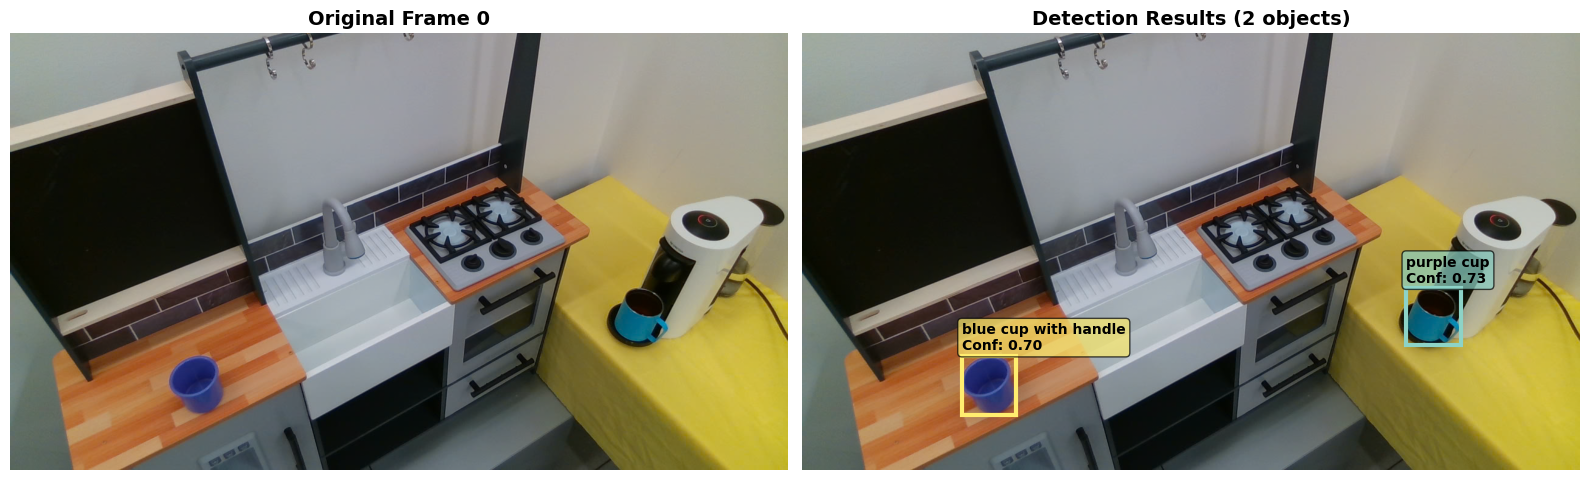


Detection summary:
  Frame: 0
  Objects requested: 4
  Objects detected: 2
  Detected labels: ['purple cup', 'blue cup with handle']


In [9]:
# ============================================================================
# Step 6 (前置): 使用DETIC+CLIP进行目标检测并可视化结果
# ============================================================================
# 在生成场景图之前，先用检测器直接检测目标并可视化

print("=" * 60)
print("DIRECT OBJECT DETECTION WITH DETIC+CLIP")
print("=" * 60)

# 检查detector类型
detector_type = type(detector).__name__
print(f"🔍 Detector: {detector_type}")

if detector_type != 'DeticClipDetector':
    print(f"⚠️  Warning: Detector is {detector_type}, not DeticClipDetector")
    print("   Make sure you ran Cell 9 with DETECTION_METHOD='detic_clip'")
else:
    print(f"✅ Using DETIC + CLIP detector")
    print(f"   DETIC threshold: {getattr(detector, 'detic_threshold', 'N/A')}")
    print(f"   CLIP threshold: {getattr(detector, 'clip_threshold', 'N/A')}")

# 获取对象列表
object_list = task_info.get('object_list', [])
print(f"📋 Objects to detect: {object_list}")
print("=" * 60)

# 使用第一帧进行检测演示
if len(frame_data) > 0:
    first_frame_idx = sorted(frame_data.keys())[0]
    first_frame = frame_data[first_frame_idx]
    
    print(f"\n📸 Detecting objects in frame {first_frame_idx}...")
    
    # 转换为PIL Image
    from PIL import Image
    rgb_pil = Image.fromarray(first_frame['rgb'])
    
    # 使用检测器进行检测
    detections = detector.detect_objects(rgb_pil, object_list)
    
    print(f"\n✅ Detection complete: Found {len(detections)} objects\n")
    
    # 打印检测结果
    if len(detections) > 0:
        for i, det in enumerate(detections):
            label = det.get('label', 'unknown')
            confidence = det.get('confidence', 0.0)
            bbox = det.get('bbox', [0, 0, 0, 0])
            clip_score = det.get('clip_score', None)
            
            print(f"  Detection {i+1}:")
            print(f"    Label: {label}")
            print(f"    Confidence: {confidence:.3f}")
            if clip_score is not None:
                print(f"    CLIP Score: {clip_score:.3f}")
            print(f"    BBox: [{int(bbox[0])}, {int(bbox[1])}, {int(bbox[2])}, {int(bbox[3])}]")
            print(f"    Size: {int(bbox[2]-bbox[0])}x{int(bbox[3]-bbox[1])}")
            print()
    else:
        print("  ⚠️  No objects detected")
        print("  Possible reasons:")
        print("    1. Objects not in view")
        print("    2. Threshold too high")
        print("    3. Object names don't match DETIC vocabulary")
        print()
    
    # 可视化检测结果
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # 左侧：原始图像
    axes[0].imshow(first_frame['rgb'])
    axes[0].set_title(f'Original Frame {first_frame_idx}', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # 右侧：检测结果可视化
    axes[1].imshow(first_frame['rgb'])
    axes[1].set_title(f'Detection Results ({len(detections)} objects)', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # 绘制检测框
    if len(detections) > 0:
        # 为每个检测分配颜色
        colors = plt.cm.Set3(np.linspace(0, 1, len(detections)))
        
        for i, det in enumerate(detections):
            bbox = det.get('bbox', [0, 0, 0, 0])
            label = det.get('label', 'unknown')
            confidence = det.get('confidence', 0.0)
            clip_score = det.get('clip_score', None)
            
            # 确保bbox格式正确 [x1, y1, x2, y2]
            x1, y1, x2, y2 = float(bbox[0]), float(bbox[1]), float(bbox[2]), float(bbox[3])
            width = x2 - x1
            height = y2 - y1
            
            # 绘制边界框
            rect = mpatches.Rectangle(
                (x1, y1), width, height,
                linewidth=3, edgecolor=colors[i], facecolor='none'
            )
            axes[1].add_patch(rect)
            
            # 添加标签和置信度
            label_text = f"{label}"
            if clip_score is not None:
                label_text += f"\nCLIP: {clip_score:.2f}"
            label_text += f"\nConf: {confidence:.2f}"
            
            axes[1].text(
                x1, y1 - 10,
                label_text,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.7),
                fontsize=10,
                color='black',
                fontweight='bold'
            )
        
        print(f"✅ Visualization complete: {len(detections)} objects detected and visualized")
    else:
        axes[1].text(
            0.5, 0.5,
            'No objects detected',
            transform=axes[1].transAxes,
            fontsize=16,
            ha='center',
            va='center',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5)
        )
        print("⚠️  No objects to visualize")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*60}")
    print("Detection summary:")
    print(f"  Frame: {first_frame_idx}")
    print(f"  Objects requested: {len(object_list)}")
    print(f"  Objects detected: {len(detections)}")
    if len(detections) > 0:
        detected_labels = [det.get('label', 'unknown') for det in detections]
        print(f"  Detected labels: {detected_labels}")
    print(f"{'='*60}")
else:
    print("⚠️  No frame data available")



In [10]:
# # 在检测之前，直接可视化DETIC的原始检测结果
# import numpy as np
# import cv2
# from PIL import Image
# import matplotlib.pyplot as plt

# # 将PIL图像转换为numpy数组（BGR格式，DETIC需要）
# img_array = np.array(rgb_pil)
# if len(img_array.shape) == 3 and img_array.shape[2] == 3:
#     img_array_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
# else:
#     img_array_bgr = img_array

# # 运行DETIC
# outputs = detector.detic_model(img_array_bgr)
# instances = outputs["instances"]

# # 过滤并限制
# valid_instances = instances[instances.scores >= detector._detic_threshold]
# if len(valid_instances) > 50:
#     top_indices = valid_instances.scores.topk(50).indices
#     valid_instances = valid_instances[top_indices]

# print(f"🔍 Raw DETIC detections: {len(instances)} total, {len(valid_instances)} after filtering")
# print(f"   Sample detections (first 10):")
# for i in range(min(10, len(valid_instances))):
#     bbox = valid_instances.pred_boxes[i].tensor.cpu().numpy()[0]
#     score = valid_instances.scores[i].cpu().item()
#     class_id = valid_instances.pred_classes[i].cpu().item()
#     x1, y1, x2, y2 = bbox
#     width = x2 - x1
#     height = y2 - y1
#     print(f"      {i}: bbox=[{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}], size={width:.1f}x{height:.1f}, score={score:.3f}, class_id={class_id}")

# # 可视化
# fig, ax = plt.subplots(1, 1, figsize=(16, 12))
# ax.imshow(rgb_pil)
# ax.set_title(f"Raw DETIC Detections ({len(valid_instances)} instances)", fontsize=14, fontweight='bold')
# ax.axis('off')

# import matplotlib.patches as mpatches
# colors = plt.cm.tab20(np.linspace(0, 1, len(valid_instances)))

# for i in range(len(valid_instances)):
#     bbox = valid_instances.pred_boxes[i].tensor.cpu().numpy()[0]
#     score = valid_instances.scores[i].cpu().item()
#     class_id = valid_instances.pred_classes[i].cpu().item()
    
#     x1, y1, x2, y2 = float(bbox[0]), float(bbox[1]), float(bbox[2]), float(bbox[3])
#     width = x2 - x1
#     height = y2 - y1
    
#     # 即使无效也绘制（用虚线）
#     linestyle = '--' if width <= 0 or height <= 0 else '-'
#     rect = mpatches.Rectangle(
#         (x1, y1), width, height,
#         linewidth=2, edgecolor=colors[i], facecolor='none', linestyle=linestyle
#     )
#     ax.add_patch(rect)
    
#     label_text = f"cls_{class_id}\n{score:.2f}\n{width:.0f}x{height:.0f}"
#     if width <= 0 or height <= 0:
#         label_text += "\n⚠️"
    
#     ax.text(x1, y1-5, label_text, 
#             bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.7),
#             fontsize=6, color='black', fontweight='bold')

# plt.tight_layout()
# plt.show()

In [11]:
# Generate scene graphs for each key frame with Environment Memory integration
scene_graphs = {}
scene_graphs_with_memory = {}  # Scene graphs after memory smoothing
object_list = task_info.get('object_list', [])
distractor_list = task_info.get('distractor_list', [])

# Display detector information
detector_type = type(detector).__name__
print("=" * 60)
print("SCENE GRAPH GENERATION WITH ENVIRONMENT MEMORY")
print("=" * 60)
print(f"🔍 Detector: {detector_type}")
if detector_type == 'DeticClipDetector':
    print(f"   Model: DETIC + CLIP (Open-vocabulary detection)")
    print(f"   Threshold: {getattr(detector, 'detic_threshold', getattr(detector, 'threshold', 'N/A'))}")
elif detector_type == 'MDETRDetector':
    print(f"   Model: MDETR (Multi-modal DETR)")
    print(f"   Threshold: {getattr(detector, 'threshold', 'N/A')}")
else:
    print(f"   Model: {detector_type}")
    print(f"   Threshold: {getattr(detector, 'threshold', 'N/A')}")
print(f"📋 Objects to detect: {object_list}")
print("=" * 60)

# Process frames in temporal order for memory tracking
sorted_frames = sorted(frame_data.keys())
print(f"\n📊 Processing {len(sorted_frames)} key frames...\n")

for step_idx in sorted_frames:
    data = frame_data[step_idx]
    
    try:
        # Step 1: Generate raw scene graph using ReflectSceneGraphBuilder
        scene_graph = scene_graph_builder.process_frame(
            rgb=data['rgb'],
            depth=data['depth'],
            step_idx=step_idx,
            object_list=object_list,
            distractor_list=distractor_list,
            task_info=task_info
        )
        
        scene_graphs[step_idx] = scene_graph
        
        # Step 2: Prepare detections for Environment Memory
        detections_for_memory = []
        for node in scene_graph.nodes:
            detection = {
                'name': node.name,
                'label': node.name,
                'object_type': getattr(node, 'object_type', node.name),
                'position_3d': node.position,
                'confidence': getattr(node, 'confidence', 1.0),
                'bbox': getattr(node, 'bbox', None),
                'attributes': getattr(node, 'attributes', {})
            }
            detections_for_memory.append(detection)
        
        # Step 3: Extract relations for memory
        relations_for_memory = []
        for (start_name, end_name), edge in scene_graph.edges.items():
            relations_for_memory.append((
                start_name,
                end_name,
                edge.edge_type,
                getattr(edge, 'confidence', 1.0)
            ))
        
        # Step 4: Update Environment Memory
        timestamp = step_idx * 0.1  # Approximate: 10 fps
        world_state = environment_memory.update(
            detections=detections_for_memory,
            relations=relations_for_memory,
            timestamp=timestamp
        )
        
        # Step 5: Create smoothed scene graph from memory
        smoothed_sg = SceneGraph(task=task_info)
        
        # Add nodes with memory-smoothed positions and confidence
        for obj_name, obj_state in world_state['objects'].items():
            # Check if object exists in original scene graph
            original_node = scene_graph.get_node(obj_name)
            if original_node is None and obj_state['occluded']:
                # Object is occluded, create node from memory
                node = Node(
                    name=obj_name,
                    object_type=obj_state['object_type'],
                    position=tuple(obj_state['position']) if obj_state['position'] else None,
                    attributes=obj_state['attributes']
                )
                # Add confidence and occlusion info
                node.attributes['confidence'] = obj_state['confidence']
                node.attributes['occluded'] = obj_state['occluded']
                node.attributes['position_variance'] = obj_state['position_variance']
                smoothed_sg.add_node(node)
            elif original_node is not None:
                # Object detected, use original but update with memory info
                node = Node(
                    name=original_node.name,
                    object_type=getattr(original_node, 'object_type', obj_name),
                    position=tuple(obj_state['position']) if obj_state['position'] else original_node.position,
                    attributes=getattr(original_node, 'attributes', {}).copy()
                )
                node.attributes['confidence'] = obj_state['confidence']
                node.attributes['occluded'] = obj_state['occluded']
                node.attributes['position_variance'] = obj_state['position_variance']
                smoothed_sg.add_node(node)
        
        # Add edges with memory-stabilized confidence
        for (obj1, obj2), rel_state in world_state['relations'].items():
            node1 = smoothed_sg.get_node(obj1)
            node2 = smoothed_sg.get_node(obj2)
            if node1 and node2:
                edge = Edge(
                    start=node1,
                    end=node2,
                    edge_type=rel_state['relation_type'],
                    confidence=rel_state['confidence']
                )
                smoothed_sg.add_edge(edge)
        
        scene_graphs_with_memory[step_idx] = smoothed_sg
        
        # Display concise scene graph summary
        print(f"Frame {step_idx} (stage {data['stage']}): ", end="")
        if len(smoothed_sg.nodes) > 0:
            node_names = [node.name for node in smoothed_sg.nodes]
            print(f"✅ {len(smoothed_sg.nodes)} objects, {len(smoothed_sg.edges)} relations")
            print(f"   Objects: {', '.join(node_names)}")
            if len(smoothed_sg.edges) > 0:
                # Show first 3 relations
                edge_samples = list(smoothed_sg.edges.items())[:3]
                relations_str = ", ".join([f"{e.start.name}--[{e.edge_type}]-->{e.end.name}" 
                                          for _, e in edge_samples])
                if len(smoothed_sg.edges) > 3:
                    relations_str += f" ... (+{len(smoothed_sg.edges)-3} more)"
                print(f"   Relations: {relations_str}")
        else:
            print(f"⚠️  No objects detected")
        
        # Show debug info for DETIC + CLIP if no detections
        if detector_type == 'DeticClipDetector' and len(scene_graph.nodes) == 0:
            print(f"    ⚠️  No objects detected in raw scene graph!")
            # Check DETIC status
            detic_available = getattr(detector, 'detic_available', False)
            detic_model = getattr(detector, 'detic_model', None)
            clip_available = getattr(detector, 'clip_available', False)
            
            if not detic_available or detic_model is None:
                print(f"    ⚠️  DETIC model not loaded (NumPy compatibility issue?)")
                print(f"    💡 Using CLIP-only fallback detection")
                if clip_available:
                    print(f"    ✅ CLIP is available, should use CLIP-only detection")
                else:
                    print(f"    ❌ CLIP also not available!")
            else:
                print(f"    ✅ DETIC model is loaded")
                detic_threshold = getattr(detector, 'detic_threshold', getattr(detector, 'threshold', 0.3))
                print(f"    DETIC threshold: {detic_threshold}")
            
            # Try direct detection for debugging
            print(f"\n    🔍 Trying direct detection call...")
            try:
                from PIL import Image
                rgb_pil = Image.fromarray(data['rgb'])
                debug_detections = detector.detect_objects(rgb_pil, object_list)
                
                if len(debug_detections) > 0:
                    print(f"    ✅ Found {len(debug_detections)} detections:")
                    for det in debug_detections[:5]:  # Show first 5
                        conf = det.get('confidence', 0)
                        label = det.get('label', 'N/A')
                        print(f"      - {label}: confidence={conf:.3f}")
                else:
                    print(f"    ❌ No detections returned")
                    print(f"    This suggests:")
                    if not detic_available or detic_model is None:
                        print(f"      - DETIC not loaded, CLIP-only detection may need adjustment")
                        print(f"      - Try lowering CLIP threshold (current: {getattr(detector, 'clip_threshold', 0.25)})")
                    else:
                        print(f"      - Objects may not be in the image")
                        print(f"      - Object names may not match detector expectations")
            except Exception as debug_e:
                print(f"    ⚠️  Debug detection failed: {debug_e}")
                import traceback
                traceback.print_exc()
        
        # Show MDETR-specific debug if using MDETR and no detections
        elif detector_type == 'MDETRDetector' and len(scene_graph.nodes) == 0:
            # Get actual detector threshold
            actual_threshold = getattr(detector, 'threshold', DETECTION_THRESHOLD)
            print(f"    ⚠️  No objects detected in raw scene graph!")
            print(f"    Detector threshold: {actual_threshold}")
            print(f"    Possible reasons: threshold too high, objects not in view, or name mismatch")
            print(f"    \n    💡 Note: The optimized MDETR detector should automatically:")
            print(f"       - Try multiple prompt variations for each object")
            print(f"       - Use adaptive thresholds")
            print(f"       - Print detailed debugging information")
            print(f"    \n    If you don't see detailed detection logs above, the module may not have reloaded.")
            print(f"    Try: Kernel → Restart Kernel, then re-run all cells from the beginning.")
        
    except Exception as e:
        print(f"  ⚠️  Error processing frame {step_idx}: {e}")
        import traceback
        traceback.print_exc()
        # Create empty scene graph as fallback
        scene_graphs[step_idx] = SceneGraph(task=task_info)
        scene_graphs_with_memory[step_idx] = SceneGraph(task=task_info)


print(f"\n{'='*60}")
print(f"✅ Processing complete: {len(scene_graphs_with_memory)} frames processed")
print(f"✅ Generated {len(scene_graphs_with_memory)} memory-smoothed scene graphs")
print(f"{'='*60}")

# Use memory-smoothed scene graphs for subsequent steps
scene_graphs = scene_graphs_with_memory


SCENE GRAPH GENERATION WITH ENVIRONMENT MEMORY
🔍 Detector: DeticPredictorWrapper
   Model: DeticPredictorWrapper
   Threshold: N/A
📋 Objects to detect: ['coffee machine', 'purple cup', 'blue cup with handle', 'table on the left of sink']

📊 Processing 9 key frames...

  ⚠️  Error processing frame 0: name 'scene_graph_builder' is not defined
  ⚠️  Error processing frame 921: name 'scene_graph_builder' is not defined
  ⚠️  Error processing frame 941: name 'scene_graph_builder' is not defined
  ⚠️  Error processing frame 2124: name 'scene_graph_builder' is not defined
  ⚠️  Error processing frame 2144: name 'scene_graph_builder' is not defined
  ⚠️  Error processing frame 4722: name 'scene_graph_builder' is not defined
  ⚠️  Error processing frame 4742: name 'scene_graph_builder' is not defined
  ⚠️  Error processing frame 5937: name 'scene_graph_builder' is not defined
  ⚠️  Error processing frame 5957: name 'scene_graph_builder' is not defined

✅ Processing complete: 9 frames processed


Traceback (most recent call last):
  File "/tmp/ipykernel_3817410/494876476.py", line 34, in <module>
    scene_graph = scene_graph_builder.process_frame(
NameError: name 'scene_graph_builder' is not defined
Traceback (most recent call last):
  File "/tmp/ipykernel_3817410/494876476.py", line 34, in <module>
    scene_graph = scene_graph_builder.process_frame(
NameError: name 'scene_graph_builder' is not defined
Traceback (most recent call last):
  File "/tmp/ipykernel_3817410/494876476.py", line 34, in <module>
    scene_graph = scene_graph_builder.process_frame(
NameError: name 'scene_graph_builder' is not defined
Traceback (most recent call last):
  File "/tmp/ipykernel_3817410/494876476.py", line 34, in <module>
    scene_graph = scene_graph_builder.process_frame(
NameError: name 'scene_graph_builder' is not defined
Traceback (most recent call last):
  File "/tmp/ipykernel_3817410/494876476.py", line 34, in <module>
    scene_graph = scene_graph_builder.process_frame(
NameError: na

## Step 8: 可视化场景图和检测结果

### 📊 可视化内容

为每一帧生成组合可视化图像，包括：

1. **左侧：RGB图像 + 检测框**
   - 原始RGB图像
   - 标注的2D边界框
   - 对象标签和置信度分数

2. **右上：场景图可视化**
   - 使用NetworkX绘制场景图
   - 节点表示对象
   - 边表示空间关系

3. **右下：统计信息**
   - 帧编号和阶段信息
   - 场景图统计（节点数、边数）
   - 检测到的对象列表
   - 关系列表

### 💾 输出

所有可视化图像保存在 `output/frame_visualizations/` 目录下，文件命名格式：`frame_XXXXX_rgb_sg.png`

这些可视化图像可以帮助你：
- 验证检测结果是否正确
- 理解场景图结构
- 调试检测问题


## Step 9: 从场景图生成约束（动作感知）

### 🎯 约束生成说明

本步骤根据场景图和任务信息生成动作感知的逻辑约束。

### 📝 约束类型

1. **前置条件（Preconditions）**
   - 动作执行前必须满足的条件
   - 例如："Pick up cup"的前置条件：cup必须存在且可达

2. **后置条件（Postconditions）**
   - 动作执行后应该满足的条件
   - 例如："Pick up cup"的后置条件：cup应该被拿起

3. **不变式（Invariants）**
   - 在整个任务执行过程中应该保持的条件
   - 例如：容器不能同时是满的和空的

### 🔧 生成方法

支持两种约束生成方法：

- **LLM方法**：使用GPT模型生成约束（需要API key）
- **模板方法**：使用预定义模板生成约束（不需要API key，推荐用于测试）

在代码中通过 `CONSTRAINT_GENERATION_METHOD` 变量选择方法。


In [12]:
# Action-aware Constraint Generation
# 选择约束生成方法：'llm' 使用 LLM，'template' 使用模板化方法
CONSTRAINT_GENERATION_METHOD = 'template'  # 修改这里：'llm' 或 'template'

print("=" * 60)
print(f"CONSTRAINT GENERATION (Method: {CONSTRAINT_GENERATION_METHOD.upper()})")
print("=" * 60)

# 根据方法选择初始化
if CONSTRAINT_GENERATION_METHOD == 'llm':
    if llm_prompter is None:
        print("⚠️  LLM Prompter 不可用，切换到模板化方法")
        CONSTRAINT_GENERATION_METHOD = 'template'
        constraint_generator = ConstraintGenerator(llm_prompter=None)
    else:
        constraint_generator = ConstraintGenerator(llm_prompter)
else:
    # 模板化方法不需要 LLM
    constraint_generator = ConstraintGenerator(llm_prompter=None)

# 获取最终场景图（用于约束生成）
final_sg = scene_graphs.get(max(scene_graphs.keys())) if scene_graphs else None
if final_sg is None:
    print("⚠️  No scene graphs available, skipping constraint generation")
    constraints = []
else:
    try:
        actions = task_info.get('actions', [])
        
        if CONSTRAINT_GENERATION_METHOD == 'llm':
            # 1. 调用 LLM 进行动作感知实例化
            constraints = constraint_generator.generate_constraints(
                scene_graph=final_sg,
                task_info=task_info,
                goal=task_info.get('success_condition', '')
            )
        
            # 2. 精确绑定到动作索引 (Action Binding) - 仅 LLM 方法需要
            action_bound_constraints = []
            for constraint in constraints:
                raw_desc = constraint.get('description', '')
                template = str(constraint.get('template') or 'N/A')
                llm_action_str = str(constraint.get('action', '')).lower()
                
                bound_action = None
                action_index = None
                
                # A. 优先尝试 LLM 提供的动作字符串匹配
                if llm_action_str and llm_action_str != 'n/a':
                    clean_llm_action = llm_action_str.split(':')[-1].strip()
                    for idx, act in enumerate(actions):
                        if clean_llm_action in act.lower() or act.lower() in clean_llm_action:
                            bound_action = act
                            action_index = idx
                            break
                
                # B. 语义绑定 (基于模板对象和动作关键词)
                if action_index is None:
                    import re
                    objs_in_template = re.findall(r'\((.*?)\)', template)
                    objs_to_match = [p.strip().lower() for p in objs_in_template[0].split(',')] if objs_in_template else []
                    desc_objs = [o.lower() for o in re.findall(r'\b([A-Z][a-zA-Z0-9]+)\b', raw_desc)]
                    objs_to_match = list(set([o for o in objs_to_match + desc_objs if len(o) > 2]))
                    
                    for idx, act in enumerate(actions):
                        act_lower = act.lower()
                        if any(obj in act_lower for obj in objs_to_match):
                            is_type_match = False
                            is_navigate = 'navigate' in act_lower
                            
                            if 'reachable' in template.lower():
                                is_type_match = is_navigate
                            elif 'holding' in template.lower():
                                is_type_match = not is_navigate and not any(kw in act_lower for kw in ['pick', 'grab', 'take'])
                            else:
                                is_type_match = not is_navigate
                            
                            if is_type_match:
                                bound_action = act
                                action_index = idx
                                break

                constraint['bound_action'] = bound_action
                constraint['action_index'] = action_index
                action_bound_constraints.append(constraint)
            
            constraints = action_bound_constraints
        else:
            # 模板化方法：直接从动作序列生成约束
            constraints = constraint_generator.generate_constraints_from_templates(
                action_strings=actions,
                compile_constraints=True
            )
            
            # 模板化方法生成的约束已经绑定了动作，只需格式化输出
            # 将约束转换为与 LLM 方法兼容的格式
            action_bound_constraints = []
            for constraint in constraints:
                action = constraint.get('action', {})
                action_bound_constraints.append({
                    'id': constraint.get('id', ''),
                    'type': constraint.get('type', ''),
                    'template': constraint.get('template', ''),
                    'description': constraint.get('description', ''),
                    'bound_action': action.get('original', ''),
                    'action_index': action.get('step_idx'),
                    'predicate': constraint.get('predicate', ''),
                    'args': constraint.get('args', []),
                    'executable': constraint.get('executable'),  # 可执行函数
                    'condition_expr': constraint.get('condition_expr', '')
                })
            
            constraints = action_bound_constraints
        
        print(f"✅ Generated {len(constraints)} action-aware constraints")
        print("\nConstraints:")
        for i, constraint in enumerate(constraints, 1):
            c_type = str(constraint.get('type', '')).lower()
            type_label = "[PRE]" if 'pre' in c_type else "[POST]" if 'post' in c_type else "[INV]" if 'inv' in c_type else "[GOAL]"
            
            # 优先显示 Description
            description = constraint.get('description', constraint.get('template', 'N/A'))
            
            idx = constraint.get('action_index')
            step_str = f"Step {idx+1}" if idx is not None else "Step ?"
            bound_action = constraint.get('bound_action', 'N/A')
            
            print(f"\n{i}. {type_label} {description}")
            print(f"   -> Action: {bound_action} ({step_str})")
            
    except Exception as e:
        print(f"⚠️  Error generating constraints: {e}")
        import traceback
        traceback.print_exc()
        constraints = []


CONSTRAINT GENERATION (Method: TEMPLATE)
✅ Generated 0 action-aware constraints

Constraints:


## Step 10: 编译约束为可执行代码（动作感知编译）

### 🔧 编译说明

将约束转换为可执行的Python表达式，用于后续的约束验证。

### 📝 编译过程

1. **语义映射**：将约束描述映射到可执行逻辑
   - 例如："cup is empty" → `len([e for e in scene_graph.edges.values() if e.end.name == 'cup' and e.edge_type == 'inside']) == 0`

2. **动作绑定**：将约束绑定到具体动作
   - 每个约束都知道它属于哪个动作步骤

3. **代码生成**：生成可执行的Python表达式
   - 这些表达式可以在场景图上直接执行

编译后的约束将用于下一步的失败检测。


In [13]:
# Constraint Compilation (基于动作模板映射)
print("=" * 60)
print("CONSTRAINT CODE GENERATION (Action-aware Compilation)")
print("=" * 60)

compiled_constraints = []

for constraint in constraints:
    # 统一规范化 template 名称
    raw_template = str(constraint.get('template', '')).lower()
    description = constraint.get('description', '')
    
    # 核心编译逻辑：将动作语义模板映射为可执行 Python 代码
    condition_expr = "True"
    
    if 'holding' in raw_template:
        condition_expr = "node.attributes.get('isPickedUp', False)"
    elif 'empty' in raw_template:
        condition_expr = "len([e for e in scene_graph.edges.values() if e.end.name == node.name and e.edge_type == 'inside']) == 0"
    elif 'filled' in raw_template:
        condition_expr = "node.attributes.get('isFilled', False)"
    elif 'toggled' in raw_template or 'is_on' in raw_template:
        if 'not' in raw_template or 'off' in raw_template:
            condition_expr = "not node.attributes.get('isToggled', False)"
        else:
            condition_expr = "node.attributes.get('isToggled', False)"
    elif 'on_top_of' in raw_template or 'is_on' in raw_template:
        condition_expr = "has_edge(node.name, target_name, 'on_top_of')"
    elif 'inside' in raw_template or 'is_in' in raw_template:
        condition_expr = "has_edge(node.name, target_name, 'inside')"
    elif 'reachable' in raw_template:
        condition_expr = "node is not None"
    elif 'gripper_empty' in raw_template:
        # 机器人状态：如果没有 node 被标记为 isPickedUp，则认为 gripper 为空
        condition_expr = "not any(n.attributes.get('isPickedUp', False) for n in scene_graph.nodes)"
    
    compiled_constraints.append({
        'original': constraint,
        'type': constraint.get('type', 'pre'),
        'condition_expr': condition_expr,
        'description': description,
        'template': raw_template
    })

print(f"✅ Compiled {len(compiled_constraints)} action-aware constraints")
for i, comp in enumerate(compiled_constraints, 1):
    orig = comp['original']
    step_info = f"Step {orig['action_index']+1}: {orig['bound_action']}" if orig.get('action_index') is not None else "Step ?"
    print(f"   {i}. [{comp['type'].upper()}] {comp['template']} -> {step_info} | Logic: {comp['condition_expr']}")


CONSTRAINT CODE GENERATION (Action-aware Compilation)
✅ Compiled 0 action-aware constraints


## Step 11: 使用约束验证进行失败检测（置信度感知）

### 🎯 失败检测说明

本步骤通过验证约束来检测任务执行失败。使用动作感知的约束检查，正确评估前置条件和后置条件。

### 🔍 检测流程

1. **按动作顺序检查约束**
   - 从第一个动作开始，依次检查每个动作的前置条件和后置条件
   - 如果前置条件失败，立即停止（动作无法执行）

2. **置信度感知验证**
   - 只有当置信度高于阈值时才报告失败
   - 如果置信度太低，标记为UNCERTAIN（避免误报）

3. **失败类型分类**
   - **前置条件违反（Precondition Violation）**：动作执行前条件不满足
   - **后置条件违反（Postcondition Violation）**：动作执行后预期结果未达到
   - **目标未达成（Goal Not Achieved）**：任务最终目标未实现

### ✨ 真实环境增强

- **置信度感知验证**：只有在置信度高于阈值时才报告失败
- **环境记忆集成**：使用记忆平滑的场景图，减少噪声影响
- **遮挡处理**：区分感知误差（对象被遮挡）和动作失败（对象真的不存在）
- **UNCERTAIN状态**：当置信度太低时返回UNCERTAIN，避免误报失败

### 📊 输出结果

检测结果包含：
- 失败的动作步骤
- 失败类型和原因
- 置信度分数
- 违反的约束详情


In [14]:
def find_node_by_name(scene_graph: SceneGraph, obj_name: str) -> Node:
    """
    在场景图中查找节点（支持精确匹配和部分匹配）
    """
    if not obj_name:
        return None
    
    # 先尝试精确匹配
    node = scene_graph.get_node(obj_name)
    if node:
        return node
    
    # 尝试部分匹配（对象名称）
    obj_name_lower = obj_name.lower()
    for n in scene_graph.nodes:
        if obj_name_lower in n.name.lower() or n.name.lower() in obj_name_lower:
            return n
        # 尝试对象类型匹配
        if obj_name_lower in n.object_type.lower() or n.object_type.lower() in obj_name_lower:
            return n
    
    return None


def extract_object_names_from_description(description: str) -> List[str]:
    """
    从约束描述中提取对象名称
    支持多种格式：Coffee machine, CoffeeMachine, Mug, etc.
    """
    import re
    
    # 提取大写开头的单词（通常是对象名）
    obj_matches = re.findall(r'\b([A-Z][a-zA-Z]+)\b', description)
    
    # 也尝试提取 "X Y" 格式（例如 "Coffee machine"）
    # 查找 "X Y must be" 或 "X Y is" 等模式
    pattern_matches = re.findall(r'\b([A-Z][a-z]+(?:\s+[a-z]+)?)\s+(?:must|is|should|can)', description, re.IGNORECASE)
    for match in pattern_matches:
        # 将 "Coffee machine" 转换为可能的对象名变体
        words = match.split()
        if len(words) == 2:
            # 尝试 "CoffeeMachine" 格式
            camel_case = words[0] + words[1].capitalize()
            if camel_case not in obj_matches:
                obj_matches.append(camel_case)
            # 也保留原始格式
            if match not in obj_matches:
                obj_matches.append(match)
    
    return obj_matches


def evaluate_constraint_with_confidence(condition_expr: str, scene_graph: SceneGraph, 
                                        node_name: str = None, target_name: str = None,
                                        environment_memory=None, confidence_threshold=0.7) -> tuple:
    """
    Evaluate constraint with confidence-aware validation (real-world)
    
    Returns:
        (is_valid: bool, reason: str, confidence: float, status: str)
        status: 'SATISFIED', 'VIOLATED', 'UNCERTAIN'
    """
    # First evaluate the constraint condition
    is_valid, reason = evaluate_constraint(condition_expr, scene_graph, node_name, target_name)
    
    # Compute confidence if memory is available
    confidence = 1.0  # Default confidence for simulation
    if environment_memory is not None:
        confidences = []
        
        # Get confidence from involved objects
        if node_name:
            obj_mem = environment_memory.get_object_state(node_name)
            if obj_mem:
                if obj_mem.occluded:
                    # Occluded object: use decayed confidence
                    confidences.append(obj_mem.confidence * 0.5)
                else:
                    confidences.append(obj_mem.confidence)
            else:
                confidences.append(0.3)  # Object not in memory
        
        if target_name:
            obj_mem = environment_memory.get_object_state(target_name)
            if obj_mem:
                if obj_mem.occluded:
                    confidences.append(obj_mem.confidence * 0.5)
                else:
                    confidences.append(obj_mem.confidence)
            else:
                confidences.append(0.3)
        
        # Get confidence from relations if checking spatial relations
        if node_name and target_name:
            rel_mem = environment_memory.relation_memories.get((node_name, target_name))
            if rel_mem:
                # Relation stability affects confidence
                stability_factor = min(rel_mem.stable_count / 5.0, 1.0)
                confidences.append(rel_mem.confidence * stability_factor)
        
        # Use minimum confidence (weakest link principle)
        confidence = min(confidences) if confidences else 0.5
    
    # Determine status
    if confidence < confidence_threshold:
        status = 'UNCERTAIN'
    elif not is_valid:
        status = 'VIOLATED'
    else:
        status = 'SATISFIED'
    
    return (is_valid, reason, confidence, status)


def evaluate_constraint(condition_expr: str, scene_graph: SceneGraph, node_name: str = None, target_name: str = None) -> tuple:
    """
    评估约束条件
    """
    try:
        # 创建辅助函数
        def has_edge(start, end, edge_type):
            edge_key = (start, end) if isinstance(scene_graph.edges, dict) else None
            if edge_key and edge_key in scene_graph.edges:
                edge = scene_graph.edges[edge_key]
                return edge.edge_type == edge_type
            # 也尝试查找边
            for edge_id, edge in scene_graph.edges.items():
                if isinstance(edge_id, tuple):
                    if edge_id[0] == start and edge_id[1] == end and edge.edge_type == edge_type:
                        return True
                elif edge.start.name == start and edge.end.name == end and edge.edge_type == edge_type:
                    return True
            return False
        
        # 查找节点（支持部分匹配）
        node = None
        if node_name:
            node = find_node_by_name(scene_graph, node_name)
        
        # 对于容器检查，如果节点找不到，尝试查找容器节点
        if not node and node_name:
            # 尝试查找容器（例如 "CoffeeMachine" 可能匹配 "CoffeeMachine-1"）
            for n in scene_graph.nodes:
                if (node_name.lower() in n.name.lower() or 
                    node_name.lower() in n.object_type.lower()):
                    node = n
                    break
        
        if not node:
            return False, f"Node '{node_name}' not found in scene graph"
        
        # 执行条件表达式
        result = eval(condition_expr, {
            'node': node,
            'target_name': target_name,
            'has_edge': has_edge,
            'scene_graph': scene_graph,
            'len': len,  # 添加 len 函数支持
            'list': list  # 添加 list 函数支持
        })
        
        return bool(result), f"Evaluated: {result}"
    except Exception as e:
        import traceback
        return False, f"Evaluation error: {e}\n{traceback.format_exc()}"

# Failure Detection
print("=" * 60)
print("FAILURE DETECTION")
print("=" * 60)

from typing import List, Tuple

detection_results = {}
failure_results = {}

# 获取初始和最终场景图
initial_sg = scene_graphs.get(min(scene_graphs.keys())) if scene_graphs else None
final_sg = scene_graphs.get(max(scene_graphs.keys())) if scene_graphs else None

if not compiled_constraints:
    print("⚠️  No compiled constraints available, skipping detection")
else:
    print(f"\n🔍 Detecting failures for task: {task_info.get('name', 'N/A')}")
    
    actions = task_info.get('actions', [])
    
    # 失败类型分类
    FAILURE_TYPES = {
        'PRECONDITION_VIOLATION': 'Precondition Violation',
        'POSTCONDITION_VIOLATION': 'Postcondition Violation', 
        'GOAL_NOT_ACHIEVED': 'Goal Not Achieved',
        'PHYSICAL_IMPOSSIBILITY': 'Physical Impossibility',
        'PERCEPTION_INCONSISTENCY': 'Perception Inconsistency'
    }
    
    # 按动作索引分组约束
    constraints_by_action = {}
    goal_constraints = []
    
    for comp_constraint in compiled_constraints:
        constraint_type = comp_constraint.get('type', 'unknown')
        original = comp_constraint.get('original', {})
        action_index = original.get('action_index')
        
        if constraint_type in ['goal']:
            goal_constraints.append(comp_constraint)
        else:
            if action_index is not None:
                if action_index not in constraints_by_action:
                    constraints_by_action[action_index] = {'pre': [], 'post': []}
                if 'pre' in constraint_type.lower():
                    constraints_by_action[action_index]['pre'].append(comp_constraint)
                elif 'post' in constraint_type.lower():
                    constraints_by_action[action_index]['post'].append(comp_constraint)
            else:
                # 未绑定的约束，按类型添加到对应列表
                if 'pre' in constraint_type.lower():
                    if actions:
                        constraints_by_action.setdefault(0, {'pre': [], 'post': []})['pre'].append(comp_constraint)
                elif 'post' in constraint_type.lower():
                    if actions:
                        constraints_by_action.setdefault(len(actions) - 1, {'pre': [], 'post': []})['post'].append(comp_constraint)
    
    violations = []
    satisfied = []
    
    # 按动作顺序检查（CRAFT 核心：动作级检查）
    precondition_failed = False
    failed_action_index = None
    
    for action_idx in sorted(constraints_by_action.keys()):
        if precondition_failed:
            break  # Precondition 失败后，不再检查后续动作
        
        action = actions[action_idx] if action_idx < len(actions) else None
        action_constraints = constraints_by_action[action_idx]
        
        # 检查 Preconditions（动作执行前）
        for comp_constraint in action_constraints['pre']:
            condition_expr = comp_constraint['condition_expr']
            description = comp_constraint['description']
            original = comp_constraint.get('original', {})
            bound_action = original.get('bound_action', action)
            action_index = original.get('action_index', action_idx)
            
            # 获取动作执行前的场景图（使用初始场景图或前一个关键帧）
            # 对于真实世界数据，我们使用最接近的帧
            eval_scene_graph = initial_sg if initial_sg else final_sg
            
            # 从描述中提取对象名称
            obj_names = extract_object_names_from_description(description)
            node_name = obj_names[0] if obj_names else None
            target_name = obj_names[1] if len(obj_names) > 1 else None
            
            # 评估约束（带置信度）
            is_valid, reason, confidence, status = evaluate_constraint_with_confidence(
                condition_expr, eval_scene_graph, node_name, target_name,
                environment_memory=environment_memory, confidence_threshold=0.7
            )
            
            # 如果置信度太低，标记为 UNCERTAIN，不判定为失败
            if status == 'UNCERTAIN':
                print(f"  ⚠️  Constraint uncertain (confidence={confidence:.2f} < 0.7): {description}")
                continue  # Skip this constraint
            
            if not is_valid:
                # Precondition 失败 - CRAFT 核心：立即失败，不再检查后续
                violations.append({
                    'constraint': comp_constraint,
                    'reason': reason,
                    'confidence': confidence,
                    'eval_time': f"Before Action {action_idx + 1}",
                    'node_name': node_name,
                    'failure_type': FAILURE_TYPES['PRECONDITION_VIOLATION'],
                    'action': bound_action,
                    'action_index': action_index,
                    'step': action_idx + 1
                })
                precondition_failed = True
                failed_action_index = action_idx
                break  # 立即停止检查
            else:
                satisfied.append({
                    'constraint': comp_constraint,
                    'eval_time': f"Before Action {action_idx + 1}",
                    'node_name': node_name,
                    'action': bound_action,
                    'action_index': action_index
                })
        
        # 如果 Precondition 失败，跳过 Postcondition 检查
        if precondition_failed:
            break
        
        # 检查 Postconditions（动作执行后）
        for comp_constraint in action_constraints['post']:
            condition_expr = comp_constraint['condition_expr']
            description = comp_constraint['description']
            original = comp_constraint.get('original', {})
            bound_action = original.get('bound_action', action)
            action_index = original.get('action_index', action_idx)
            
            # 获取动作执行后的场景图（使用最终场景图）
            eval_scene_graph = final_sg if final_sg else initial_sg
            
            # 从描述中提取对象名称
            obj_names = extract_object_names_from_description(description)
            node_name = obj_names[0] if obj_names else None
            target_name = obj_names[1] if len(obj_names) > 1 else None
            
            # 评估约束（带置信度）
            is_valid, reason, confidence, status = evaluate_constraint_with_confidence(
                condition_expr, eval_scene_graph, node_name, target_name,
                environment_memory=environment_memory, confidence_threshold=0.7
            )
            
            # 如果置信度太低，标记为 UNCERTAIN，不判定为失败
            if status == 'UNCERTAIN':
                print(f"  ⚠️  Constraint uncertain (confidence={confidence:.2f} < 0.7): {description}")
                continue  # Skip this constraint
            
            if not is_valid:
                violations.append({
                    'constraint': comp_constraint,
                    'reason': reason,
                    'confidence': confidence,
                    'eval_time': f"After Action {action_idx + 1}",
                    'node_name': node_name,
                    'failure_type': FAILURE_TYPES['POSTCONDITION_VIOLATION'],
                    'action': bound_action,
                    'action_index': action_index,
                    'step': action_idx + 1
                })
                # Postcondition 失败也立即停止（动作执行失败）
                precondition_failed = True
                failed_action_index = action_idx
                break
            else:
                satisfied.append({
                    'constraint': comp_constraint,
                    'eval_time': f"After Action {action_idx + 1}",
                    'node_name': node_name,
                    'action': bound_action,
                    'action_index': action_index
                })
    
    # 只有在没有 Precondition 失败的情况下，才检查 Goal
    if not precondition_failed and final_sg:
        for comp_constraint in goal_constraints:
            condition_expr = comp_constraint['condition_expr']
            description = comp_constraint['description']
            original = comp_constraint.get('original', {})
            
            # Goal 在最终状态检查
            eval_scene_graph = final_sg
            
            # 从描述中提取对象名称
            obj_names = extract_object_names_from_description(description)
            node_name = obj_names[0] if obj_names else None
            target_name = obj_names[1] if len(obj_names) > 1 else None
            
            # 评估约束（带置信度）
            is_valid, reason, confidence, status = evaluate_constraint_with_confidence(
                condition_expr, eval_scene_graph, node_name, target_name,
                environment_memory=environment_memory, confidence_threshold=0.7
            )
            
            # 如果置信度太低，标记为 UNCERTAIN，不判定为失败
            if status == 'UNCERTAIN':
                print(f"  ⚠️  Goal constraint uncertain (confidence={confidence:.2f} < 0.7): {description}")
                continue  # Skip this constraint
            
            if not is_valid:
                violations.append({
                    'constraint': comp_constraint,
                    'reason': reason,
                    'confidence': confidence,
                    'eval_time': "At Task Completion",
                    'node_name': node_name,
                    'failure_type': FAILURE_TYPES['GOAL_NOT_ACHIEVED'],
                    'action': None,
                    'action_index': None,
                    'step': 'final'
                })
            else:
                satisfied.append({
                    'constraint': comp_constraint,
                    'eval_time': "At Task Completion",
                    'node_name': node_name,
                    'action': None,
                    'action_index': None
                })
    
    detection_results = {
        'violations': violations,
        'satisfied': satisfied,
        'total_constraints': len(compiled_constraints),
        'violation_count': len(violations),
        'precondition_failed': precondition_failed,
        'failed_action_index': failed_action_index
    }
    
    # 为了兼容原有代码，也创建 failure_results
    if violations:
        failure_results['final'] = [{
            'constraint': v['constraint']['original'],
            'frame': 'final',
            'violation': True,
            'reason': v.get('reason', 'N/A'),
            'failure_type': v.get('failure_type', 'N/A')
        } for v in violations]
    
    print(f"   📊 Detection Results:")
    print(f"      Total constraints: {len(compiled_constraints)}")
    print(f"      Violations: {len(violations)}")
    print(f"      Satisfied: {len(satisfied)}")
    
    if violations:
        print(f"\n   ⚠️  Found {len(violations)} constraint violations:")
        
        # 优先显示 Precondition Violation（这是真正的失败原因）
        precondition_violations = [v for v in violations if v.get('failure_type') == FAILURE_TYPES['PRECONDITION_VIOLATION']]
        postcondition_violations = [v for v in violations if v.get('failure_type') == FAILURE_TYPES['POSTCONDITION_VIOLATION']]
        goal_violations = [v for v in violations if v.get('failure_type') == FAILURE_TYPES['GOAL_NOT_ACHIEVED']]
        
        # 显示 Precondition Violations（最重要的失败原因）
        if precondition_violations:
            print(f"\n   🚨 Precondition Violation (Failed before action execution):")
            for i, violation in enumerate(precondition_violations, 1):
                desc = violation['constraint']['description'][:70]
                reason = violation.get('reason', 'N/A')
                step = violation.get('step', '?')
                action = violation.get('action', 'N/A')
                
                print(f"      {i}. [PRECONDITION VIOLATION]")
                print(f"         Action: {action} - Step {step}")
                print(f"         Description: {desc}...")
                print(f"         Reason: {reason}")
                print(f"         ⚠️  Action is physically invalid, task cannot continue")
        
        # 显示 Postcondition Violations
        if postcondition_violations:
            print(f"\n   ⚠️  Postcondition Violation (Action did not achieve expected result):")
            for i, violation in enumerate(postcondition_violations, 1):
                desc = violation['constraint']['description'][:70]
                reason = violation.get('reason', 'N/A')
                step = violation.get('step', '?')
                action = violation.get('action', 'N/A')
                
                print(f"      {i}. [POSTCONDITION VIOLATION]")
                print(f"         Action: {action} - Step {step}")
                print(f"         Description: {desc}...")
                print(f"         Reason: {reason}")
        
        # 只有在没有 Precondition 失败时才显示 Goal Not Achieved
        if goal_violations and not precondition_failed:
            print(f"\n   📋 Goal Not Achieved (Task not completed, but not failure cause):")
            for i, violation in enumerate(goal_violations, 1):
                desc = violation['constraint']['description'][:70]
                reason = violation.get('reason', 'N/A')
                
                print(f"      {i}. [GOAL NOT ACHIEVED]")
                print(f"         Description: {desc}...")
                print(f"         Reason: {reason}")
                print(f"         ℹ️  This is task completion check, not failure cause")
        elif goal_violations and precondition_failed:
            print(f"\n   ℹ️  Goal check skipped (Precondition failed, task did not complete)")
    else:
        print(f"   ✅ All constraints satisfied, task execution successful!")

print(f"\n✅ Failure detection completed!")


NameError: name 'List' is not defined

## Step 12: 渐进式解释和失败分析

### 📝 分析说明

使用LLM生成详细的失败分析，包括因果链。

### 🔍 分析内容

1. **失败摘要**：简要描述失败情况

2. **因果链**：分析失败的因果链
   - 从根本原因到最终失败的完整链条

3. **根本原因**：识别导致失败的根本原因

4. **与真实标注对比**：与任务信息中的真实失败原因进行对比

### ⚠️ 注意

本步骤需要LLM API（如OpenAI GPT），如果API不可用，此步骤可能无法执行。


In [ ]:
# Generate progressive explanation for failures
print("=" * 60)
print("PROGRESSIVE EXPLANATION")
print("=" * 60)

if failure_results:
    for frame_idx, failures in failure_results.items():
        print(f"\n--- Failure Analysis for Frame {frame_idx} ---")
        
        scene_graph = scene_graphs[frame_idx]
        scene_description = scene_descriptions.get(frame_idx, "")
        
        try:
            explanation = failure_analyzer.analyze_failure(
                task_info=task_info,
                scene_graph=scene_graph,
                scene_description=scene_description,
                violated_constraints=[f['constraint'] for f in failures],
                frame_idx=frame_idx
            )
            
            print(f"\nFailure Explanation:")
            print(f"  {explanation.get('summary', 'N/A')}")
            
            if 'causal_chain' in explanation:
                print(f"\nCausal Chain:")
                for i, step in enumerate(explanation['causal_chain'], 1):
                    print(f"  {i}. {step}")
                    
            if 'root_cause' in explanation:
                print(f"\nRoot Cause: {explanation['root_cause']}")
                
            # Compare with ground truth
            if 'gt_failure_reason' in task_info:
                print(f"\nGround Truth Failure Reason: {task_info['gt_failure_reason']}")
                
        except Exception as e:
            print(f"⚠️  Error generating explanation: {e}")
            import traceback
            traceback.print_exc()
else:
    print("No failures detected, skipping explanation generation")


## Step 13: 总结和结果

### 📊 工作流总结

本步骤提供完整工作流执行的总结，包括：

- 处理的任务信息
- 处理的帧数和关键帧
- 检测到的对象数量
- 生成的约束数量
- 失败检测结果
- 约束违反情况

### ✅ 检查要点

1. **检测结果**：检查是否正确检测到所有目标对象
2. **场景图**：检查场景图是否正确构建
3. **约束生成**：检查约束是否正确生成和编译
4. **失败检测**：检查失败检测结果是否符合预期

如果发现问题，可以：
- 调整检测阈值
- 尝试不同的检测方法
- 检查对象名称是否匹配
- 查看可视化图像进行调试


In [ ]:
# Final summary
print("=" * 60)
print("WORKFLOW SUMMARY")
print("=" * 60)

print(f"\nTask: {task_info.get('name', 'N/A')}")
print(f"Task Folder: {TASK_FOLDER_NAME}")
print(f"Total Frames: {total_frames}")
print(f"Key Frames Processed: {len(scene_graphs)}")
print(f"Objects Detected: {len(set([node.name for sg in scene_graphs.values() for node in sg.nodes]))}")
print(f"Constraint Generation Method: {CONSTRAINT_GENERATION_METHOD.upper()}")
print(f"Constraints Generated: {len(constraints)}")
print(f"Constraints Compiled: {len(compiled_constraints)}")

if 'detection_results' in locals() and detection_results:
    print(f"\nFailure Detection Results:")
    print(f"  Total Constraints Checked: {detection_results.get('total_constraints', 0)}")
    print(f"  Violations: {detection_results.get('violation_count', 0)}")
    print(f"  Satisfied: {len(detection_results.get('satisfied', []))}")
    if detection_results.get('precondition_failed', False):
        print(f"  ⚠️  Precondition Failed at Action: {detection_results.get('failed_action_index', 'N/A')}")
    else:
        print(f"  ✅ No Precondition Violations")

if failure_results:
    total_violations = sum(len(f) for f in failure_results.values())
    print(f"\nFrames with Failures: {len(failure_results)}")
    print(f"Total Constraint Violations: {total_violations}")

print("\n" + "=" * 60)
print("✅ Workflow completed successfully!")
print("=" * 60)
